# **EC1036 - Inteligência Computacional**

# **Tópico: Florestas Aleatórias**

Nesse módulo começaremos analisando os conceitos básicos que formulam uma **Floresta Aleatória**, sua filosofia de *ensemble* e interpretação. Depois, vamos examinar como ela combina **múltiplas árvores de decisão** através de **bagging** e **aleatoriedade nas características** para tarefas de **classificação** de alta performance.

## **Bibliotecas**

In [ ]:
import os  # Módulo para interagir com o sistema operacional (manipular diretórios, arquivos, etc.)

import numpy as np  # Biblioteca fundamental para computação numérica com arrays e funções matemáticas

import matplotlib.pyplot as plt  # Biblioteca para criação de gráficos e visualizações

import pandas as pd  # Biblioteca para manipulação e análise de dados tabulares (DataFrames)

from sklearn.datasets import load_iris  # Função para carregar o dataset Iris, clássico para classificação

from sklearn.model_selection import train_test_split # Para dividir o dataset em treino e teste

from sklearn.tree import DecisionTreeClassifier  # Modelo de Árvore de Decisão para tarefas de classificação

from sklearn import datasets  # Submódulo para carregar diversos datasets de exemplo do scikit-learn

from sklearn.metrics import accuracy_score # Métricas para avaliar desempenho de modelos de classificação e regressão


## **1 - Ensemble Learning (Aprendizado por Assembleia/Agrupamento)**

Suponha que você faça uma pergunta complexa para milhares de pessoas aleatórias e, em seguida, agregue as respostas delas. Em muitos casos, essa resposta agregada será melhor do que a resposta de um especialista. Isso é conhecido como **sabedoria da multidão**.

Da mesma forma, quando você agrega as previsões de vários modelos preditores (como classificadores ou regressores), frequentemente obtém previsões melhores do que se usasse apenas o melhor modelo individualmente. Um grupo de preditores é chamado de **ensemble**; por isso, essa técnica é conhecida como **Aprendizado em Conjunto** (*Ensemble Learning*), e um algoritmo que implementa essa técnica é chamado de **método de Ensemble**.

Por exemplo, é possível treinar vários classificadores de **Árvores de Decisão**, cada um utilizando um subconjunto aleatório diferente do conjunto de treinamento. Para fazer previsões, você coleta as previsões de todas as árvores individuais e então escolhe a classe que recebeu mais votos. Esse conjunto de Árvores de Decisão é chamado de **Floresta Aleatória** (*Random Forest*), e apesar de sua simplicidade, é um dos algoritmos de **Machine Learning** mais poderosos atualmente.


### **1.1 - Classificadores por Votação: o gancho para Bagging**

Imagine que você treinou diversos classificadores, cada um com cerca de **80% de acurácia** — por exemplo, uma Regressão Logística, uma SVM, uma Floresta Aleatória e um K-Nearest Neighbors.

Uma maneira simples de criar um classificador ainda melhor é **agregar as previsões** de cada modelo e escolher a classe que receber a **maioria dos votos**. Esse modelo é chamado de **classificador por votação rígida** (*hard voting classifier*).

Surpreendentemente, essa abordagem pode alcançar uma **acurácia superior** à de qualquer classificador individual. Mesmo que cada modelo seja apenas **um pouco melhor que o acaso**, quando combinados e desde que sejam **suficientemente diversos**, o ensemble pode se tornar um **forte preditor**.

Essa ideia se apoia na **Lei dos Grandes Números**, um princípio fundamental da Estatística. Ele afirma que, à medida que realizamos um número cada vez maior de experimentos independentes, a média dos resultados tende a se aproximar da probabilidade real.

No contexto de ensembles, pense em cada classificador como uma **moeda levemente viciada**, com uma chance um pouco maior que 51% de acertar. Isoladamente, eles são apenas **aprendizes fracos** — fazem previsões um pouco melhores que o puro acaso. Mas, quando combinamos muitas dessas previsões através do **voto da maioria**, conseguimos um **resultado global muito mais confiável**.

Por exemplo, se tivermos 1.000 classificadores, cada um acertando apenas **51% das vezes**, ao combinar suas previsões pela maioria de votos, podemos atingir uma **acurácia superior a 75%**. Esse ganho ocorre porque os erros de cada classificador tendem a se **compensar** mutuamente, desde que sejam suficientemente **independentes**.

Assim como em repetidos lançamentos de uma moeda viciada, onde a proporção de caras se aproxima da probabilidade real conforme o número de lançamentos cresce, o mesmo acontece com classificadores: **quanto mais previsores, maior a estabilidade e a precisão do ensemble**.

In [ ]:
from sklearn.datasets import make_moons # Importa a função make_moons do módulo datasets da biblioteca scikit-learn
                                       # Essa função é usada para gerar um dataset sintético (artificial)
                                       # que se assemelha a duas "luas" interligadas ou meias-luas.
                                       # É um dataset muito popular para testar algoritmos de classificação
                                       # não-lineares, pois as classes não são linearmente separáveis.

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression # Importa o classificador de Regressão Logística
from sklearn.ensemble import RandomForestClassifier # Importa o classificador RandomForest (Floresta Aleatória)
from sklearn.svm import SVC                         # Importa o classificador Support Vector Machine (Máquina de Vetor de Suporte)

from sklearn.ensemble import VotingClassifier # Importa o classificador de Votação (VotingClassifier)

In [ ]:
# Inicializa um classificador de Regressão Logística.
# LogisticRegression é um modelo linear simples, mas eficaz, para problemas de classificação.
# solver="lbfgs": Define o algoritmo a ser usado para otimização, ou seja, como o modelo
#                  irá "aprender" e ajustar seus pesos para minimizar o erro (função de custo).
#                  O "lbfgs" (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) é um algoritmo
#                  da família dos métodos quase-Newton, que é eficiente e robusto para muitos
#                  datasets, especialmente quando o dataset não é muito grande. Ele tenta
#                  encontrar o mínimo da função de custo de forma iterativa, aproximando
#                  a segunda derivada (Hessiana) para determinar a direção de ajuste dos pesos.
#                  É um bom padrão e geralmente funciona bem para a maioria dos datasets.
# random_state=42: Garante que os resultados sejam reproduzíveis.
log_clf = LogisticRegression(solver="lbfgs", random_state=42)
# random_state=42: Garante que os resultados sejam reproduzíveis. Se você rodar o código
#                  várias vezes, com o mesmo random_state, obterá sempre os mesmos resultados.
log_clf = LogisticRegression(solver="lbfgs", random_state=42)

# Inicializa um classificador RandomForest.
# RandomForestClassifier é um algoritmo de ensemble (conjunto) que constrói múltiplas
# árvores de decisão durante o treinamento e gera a classe que é a moda (a mais comum)
# das classes previstas pelas árvores individuais. É robusto e geralmente performa bem.
# n_estimators=100: Define o número de árvores de decisão na floresta. Mais árvores
#                   geralmente resultam em maior precisão, mas aumentam o tempo de treinamento.
# random_state=42: Garante a reprodutibilidade dos resultados da floresta aleatória.
rnd_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Inicializa um classificador Support Vector Machine (SVM).
# SVC é um algoritmo poderoso para classificação, que busca encontrar o hiperplano
# ideal que melhor separa as classes no espaço de features.
# gamma="scale": Define como o kernel (função que mapeia os dados para um espaço de dimensão superior)
#                impacta as amostras de treinamento. "scale" usa 1 / (n_features * X.var()),
#                o que é um bom padrão e automático para a maioria dos casos.
# random_state=42: Garante a reprodutibilidade dos resultados para o SVM.
svm_clf = SVC(gamma="scale", random_state=42)

In [ ]:
# estimators: É uma lista de tuplas, onde cada tupla contém:
#             - um nome curto (string) para o classificador (ex: 'lr' para Logistic Regression).
#             - a instância do classificador já inicializada (ex: log_clf).
#             Esses classificadores individuais serão treinados e suas previsões combinadas.
estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
#
# voting: Define a estratégia de votação usada para combinar as previsões dos classificadores base.
#         Existem duas opções principais:
#         - 'hard' (Votação Rígida/Majoritária): O VotingClassifier prevê a classe que recebe
#           o maior número de votos da maioria dos classificadores individuais. Por exemplo,
#           se três classificadores preveem [0, 0, 1], a previsão final será 0.
#           É mais simples e exige que os classificadores retornem rótulos de classe discretos.
#         - 'soft' (Votação Suave/Ponderada): Se os classificadores base puderem estimar
#           probabilidades de classe (método predict_proba), o VotingClassifier soma as
#           probabilidades previstas para cada classe por todos os classificadores e prevê
#           a classe com a maior probabilidade média (ou ponderada). Isso geralmente
#           resulta em um desempenho melhor, pois considera a confiança de cada classificador.
#           Para 'soft' voting, os estimadores devem ter o atributo 'predict_proba'.
voting_clf = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', svm_clf)],
    voting='hard')

In [ ]:
for clf in (log_clf, rnd_clf, svm_clf, voting_clf):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(clf.__class__.__name__, accuracy_score(y_test, y_pred))

LogisticRegression 0.864
RandomForestClassifier 0.896
SVC 0.896
VotingClassifier 0.912


- ➡️ **Importante:** métodos de ensemble funcionam melhor quando os classificadores são o mais **independentes** possível, ou seja, cometem **erros diferentes**.

Esse conceito nos leva naturalmente ao estudo de técnicas mais sofisticadas de combinação de modelos, como o **Bagging** (*Bootstrap Aggregating*), onde múltiplos classificadores são treinados em **subconjuntos aleatórios dos dados** para reduzir a variância e melhorar o desempenho.

## **2 - Bagging (Bootstrap Aggregating)**

Segundo **[Breiman (1996)](https://sci2s.ugr.es/keel/pdf/algorithm/articulo/1996-ML-Breiman-Bagging%20Predictors.pdf)**, O Bootstrap cria **replicações do conjunto de aprendizado** ao amostrar com reposição, simulando o que aconteceria ao coletarmos novos conjuntos da mesma distribuição.

Imagine que você tem um conjunto de dados de tamanho `N`. O Bootstrap consiste em criar novos conjuntos de dados, chamados de **amostras bootstrap**, pegando `N` elementos aleatórios do conjunto original, **com a possibilidade de repetir elementos**.

➡️ Isso significa que:  
- Alguns elementos podem aparecer mais de uma vez na mesma amostra.  
- Outros podem não aparecer.

**Exemplo:**  
Se o conjunto original tem 5 elementos: `{A, B, C, D, E}`, uma amostra bootstrap poderia ser: `{B, D, D, A, E}`.

Esse processo é repetido muitas vezes, criando várias amostras bootstrap. Cada uma delas é usada para **treinar um modelo diferente**.

**Resumo visual:**  
Conjunto original → várias amostras com reposição → vários modelos.

**Curiosidade importante:**  
Quando fazemos uma amostra bootstrap com tamanho `N`, aproximadamente **37%** dos elementos do conjunto original **não aparecem** nessa amostra.  
Isso ocorre porque a chance de um elemento não ser escolhido é aproximadamente `1/e ≈ 0.37`.

---

**Bagging — como o Bootstrap é usado para melhorar modelos**

**Bagging** é a sigla para "**Bootstrap Aggregating**", ou seja, **Agregação via Bootstrap**.

A ideia do Bagging é usar o Bootstrap para criar várias amostras, treinar vários modelos, e depois **combinar esses modelos** para fazer uma previsão **mais robusta**.

**Passos do Bagging:**  
1. Criar várias amostras bootstrap a partir do conjunto de dados original.  
2. Treinar um modelo em cada amostra.  
3. Quando for fazer uma previsão, **combinar as previsões** de todos os modelos.

➡️ **Como combinar?**  
- Problema de **regressão**: tirar a **média** das previsões.  
- Problema de **classificação**: fazer uma **votação** e escolher a classe mais votada.

**Resumo visual:**  
Várias amostras → vários modelos → agregação (média ou votação).

---

**Por que o Bagging funciona?**

O Bagging melhora os resultados principalmente quando o modelo que estamos usando é **instável**.

➡️ **O que é um modelo instável?**  
É um modelo que, se você mudar um pouco os dados de treinamento, ele muda bastante suas previsões.

**Exemplos de modelos instáveis:**  
- Árvores de decisão  
- Redes neurais  
- Seleção de variáveis na regressão  

**Exemplos de modelos estáveis:**  
- K-vizinhos mais próximos (KNN)

✅ Bagging funciona muito bem com modelos instáveis → **melhora a precisão**.  
❌ Bagging não melhora (ou pode até piorar) modelos estáveis.

➡️ **Por que melhora?**  
Ao treinar vários modelos em amostras ligeiramente diferentes, os **erros de cada um tendem a se compensar** quando combinamos.  
Isso reduz a **variância** do modelo e torna a previsão **mais confiável**.

---

**Exemplo clássico: Árvores de decisão com Bagging**

- Com uma única árvore: uma pequena mudança nos dados pode mudar muito a árvore.  
- Com Bagging: várias árvores treinadas em diferentes amostras → combinação das previsões → resultado **mais estável e preciso**.

➡️ Assim nasceu o **Random Forest**:  
Bagging de várias árvores de decisão, com algumas melhorias adicionais.

---

**Duvidas que podem surgir: “Por que repetir valores? Não vai enviesar?”**

Parece contraintuitivo, mas **não é um problema**.

➡️ O objetivo do Bootstrap não é aumentar a variabilidade dos dados, mas entender como o modelo se comporta quando os dados mudam um pouco.

Repetir valores cria **variações artificiais** da amostra, simulando o que aconteceria se coletássemos novas amostras.

➡️ O Bootstrap ajuda a medir:  
- Como o modelo se altera quando os dados mudam.  
- A variabilidade ou estabilidade do modelo.

**Sobre enviesar:**  
O Bootstrap **não aumenta o viés**; ele é usado para **estimar incerteza** (como variância e intervalo de confiança).  
O viés vem da escolha da técnica e dos dados originais, não do Bootstrap.

**Dado interessante:**  
Mesmo com essa amostragem com reposição, cerca de **37%** dos dados da amostra original **não aparecem** em cada amostra bootstrap.

---

**Por fim: qual o benefício?**

Quando usamos **Bagging** (Bootstrap + Agregação), como no **Random Forest**, essa reamostragem e repetição ajudam a **reduzir a variância** do modelo e melhorar a **generalização**.

➡️ Para modelos **instáveis**, como árvores de decisão, isso é **muito poderoso**.

---

**Exemplo prático:**

Amostra original: `[10, 12, 15, 18, 20]` → `n = 5`

**Etapa 1 — Criando uma amostra Bootstrap:**  
- Sorteio 1: 15  
- Sorteio 2: 12  
- Sorteio 3: 15 (repetido)  
- Sorteio 4: 20  
- Sorteio 5: 10  

Nova amostra bootstrap: `[15, 12, 15, 20, 10]`  

✅ Repetimos o 15  
✅ Não pegamos o 18

➡️ **Isso é normal e esperado no Bootstrap!**

---

**Etapa 2 — Por que repetir?**  
Para criar várias versões da nossa amostra, como se tivéssemos coletado várias vezes, simulando a **incerteza natural**.

---

**Etapa 3 — Isso não vai enviesar?**  
Não!  
- O Bootstrap **não serve** para mudar os dados ou o modelo, mas para medir a **incerteza**.  
- O viés vem da técnica ou dos dados originais.

---

**Etapa 4 — E a variabilidade?**  
Mesmo com repetições, há variabilidade suficiente.

➡️ Em cada amostra bootstrap, cerca de **37% dos dados ficam de fora**.

**Exemplo:**  
Bootstrap 1: falta o 18  
Bootstrap 2: falta o 10 e o 12  
Bootstrap 3: falta o 20

Essa diversidade entre as amostras é essencial para:  
✅ Testar a **robustez** do modelo  
✅ Construir **intervalos de confiança**  
✅ Estimar a **variabilidade** da estatística

---

**Resumindo a ideia com este fluxograma mental:**

1. Só tenho uma amostra → preciso gerar outras para simular coletas.  
2. Faço Bootstrap → reamostro com reposição → gera amostras ligeiramente diferentes.  
3. Repetições ocorrem? → Sim, mas isso é bom → cria variações que simulam novas coletas.  
4. Vai enviesar? → Não!  
   - O viés está no modelo ou na amostra original.  
   - O Bootstrap ajuda a avaliar a **incerteza**.  
5. Variabilidade suficiente? → Sim!  
   - Porque, em média, **37% dos dados não aparecem** em cada amostra bootstrap → isso gera diversidade.

---

**Conclusão:**

- **Bootstrap** → técnica de reamostragem com reposição → cria novas amostras para estimar a **incerteza**.  
- **Bagging** → usa o Bootstrap para gerar vários modelos e combinar → reduz a **variância** e melhora a **precisão**.

➡️ Essencial para modelos **instáveis**, como **árvores de decisão** → exemplo clássico: **Random Forest**.


### **2.1 - Bagging no ``Sckit-Learn``**

O Scikit-Learn oferece uma API simples para **bagging** através da classe `BaggingClassifier` (ou `BaggingRegressor` para problemas de regressão).

O código a seguir, por exemplo, treina um *ensemble* de 500 classificadores de Árvore de Decisão. Cada um desses classificadores é treinado em 100 instâncias de treinamento, que são amostradas aleatoriamente do conjunto de treinamento **com reposição**. Este é um exemplo clássico de **bagging**. Se você preferir usar **pasting** (amostragem sem reposição), basta definir o parâmetro `bootstrap=False`.

O parâmetro `n_jobs` indica ao Scikit-Learn o número de núcleos da CPU a serem utilizados para o treinamento e as previsões. Definir `n_jobs=-1` instrui o Scikit-Learn a usar todos os núcleos disponíveis.

In [ ]:
from sklearn.ensemble import BaggingClassifier

In [ ]:
# Criação de um BaggingClassifier
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(),       # Estimador base: uma árvore de decisão
    n_estimators=500,                         # Número de estimadores: 500 árvores serão treinadas
    max_samples=100,                          # Cada árvore será treinada com uma amostra aleatória de 100 observações (com reposição)
    bootstrap=True,                           # Amostragem com reposição (bootstrap), fundamental para o método Bagging
    random_state=42                           # Semente para reprodutibilidade dos resultados
)

# Treinamento do modelo Bagging com os dados de treinamento
bag_clf.fit(X_train, y_train)

# Predição usando o modelo treinado nos dados de teste
y_pred = bag_clf.predict(X_test)

In [ ]:
print(accuracy_score(y_test, y_pred))

0.904


>Vamos fazer uma árvore de decisão para comparar:

In [ ]:
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
print(accuracy_score(y_test, y_pred_tree))

0.856


>**Faremos um gráfico para comparar:**

In [ ]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes=[-1.5, 2.45, -1, 1.5], alpha=0.5, contour=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if contour:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", alpha=alpha)
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", alpha=alpha)
    plt.axis(axes)
    plt.xlabel(r"$x_1$", fontsize=18)
    plt.ylabel(r"$x_2$", fontsize=18, rotation=0)

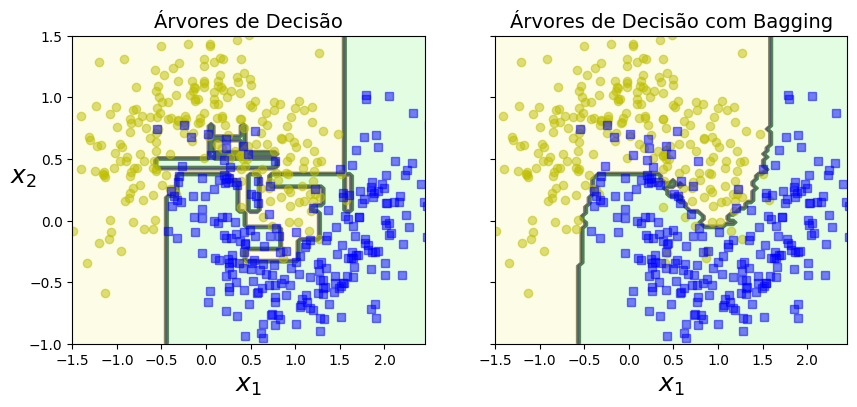

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(10,4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf, X, y)
plt.title("Árvores de Decisão", fontsize=14)
plt.sca(axes[1])
plot_decision_boundary(bag_clf, X, y)
plt.title("Árvores de Decisão com Bagging", fontsize=14)
plt.ylabel("")
plt.show()

## **3 - Random Forests**

Como já discutimos, uma **Random Forest** é um *ensemble* (conjunto) de **Árvores de Decisão**, geralmente treinadas usando o método **bagging** (ou, em alguns casos, **pasting**). Normalmente, o parâmetro `max_samples` é definido para o tamanho total do conjunto de treinamento.

Em vez de construir um `BaggingClassifier` e passar-lhe um `DecisionTreeClassifier`, você pode, de forma mais conveniente e otimizada, usar a classe **`RandomForestClassifier`** diretamente (de maneira similar, existe a classe `RandomForestRegressor` para tarefas de regressão).

O código a seguir, por exemplo, utiliza todos os núcleos de CPU disponíveis para treinar um classificador Random Forest com 500 árvores. Cada uma dessas árvores é limitada a um máximo de 16 nós, o que ajuda a controlar a complexidade e evitar o *overfitting*.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Criação de um RandomForestClassifier
rnd_clf = RandomForestClassifier(
    n_estimators=500,      # Número de árvores de decisão na floresta. Mais árvores podem reduzir o overfitting, mas aumentam o custo computacional.
    max_leaf_nodes=16,     # Número máximo de folhas em cada árvore, controlando a complexidade e ajudando a evitar overfitting.
    random_state=42        # Semente para garantir reprodutibilidade dos resultados.
)

# Treinamento do modelo Random Forest com os dados de treinamento
y_pred_rf = rnd_clf.fit(X_train, y_train)

In [ ]:
y_pred_rf

RandomForestClassifier(max_leaf_nodes=16, n_estimators=500, random_state=42)

### **3.1 - Hiperparâmetros da Random Forest**

Com poucas exceções, um `RandomForestClassifier` possui **todos os hiperparâmetros de um `DecisionTreeClassifier`** (que controlam como as árvores individuais são construídas) **mais todos os hiperparâmetros de um `BaggingClassifier`** (que controlam o *ensemble* como um todo).

**Aleatoriedade Adicional em Random Forests**

O algoritmo Random Forest introduz **aleatoriedade adicional** no processo de crescimento das árvores. Diferente de uma Árvore de Decisão padrão, que busca exaustivamente a **melhor característica** entre **todas** as disponíveis para dividir um nó, a Random Forest considera apenas um **subconjunto aleatório de características** em cada divisão.

---

**Árvore de Decisão Padrão: Busca Exaustiva**

Considere um conjunto de dados com 100 características. Uma Árvore de Decisão padrão, ao dividir um nó:

- Avalia **todas as 100 características**, testando diferentes pontos de corte.
- Calcula a qualidade de cada divisão usando critérios como *gini* ou *entropy*.
- Escolhe a **melhor opção** entre todas.

Essa busca eficiente para uma única árvore pode gerar árvores **correlacionadas** em um *ensemble*, limitando sua diversidade.

---

**Random Forest: Busca com Aleatoriedade Controlada**

Na Random Forest, cada árvore:

1. Seleciona **aleatoriamente um subconjunto de características** para cada divisão de nó (ex.: 10 de 100 características com `max_features='sqrt'`).
2. Busca a **melhor divisão apenas dentro desse subconjunto**.
3. **Repete o processo** para cada novo nó com um novo subconjunto aleatório.

O hiperparâmetro **`max_features`** controla esse processo:

| Configuração | Significado |
|--------------|-------------|
| `'sqrt'` | $\sqrt{N}$ características (padrão classificação) |
| `'log2'` | $\log_2(N)$ características |
| `0.5` | 50% das características |
| `N` (inteiro) | Exatamente N características |

---

**Exemplo Prático**

Com 100 características e `max_features='sqrt'`:

1. Nó A → seleciona aleatoriamente colunas [5, 12, 23, 30, 45, 51, 60, 78, 89, 95]
2. Busca melhor divisão entre essas 10 colunas
3. Nó B → seleciona novo subconjunto [2, 15, 28, 33, 40, 52, 65, 71, 80, 99]

---

**Vantagens: Diversidade e Robustez**

Essa aleatoriedade gera **árvores menos correlacionadas**, promovendo:

- **Maior diversidade** no *ensemble*
- **Redução da variância** (erros se cancelam)
- **Melhor generalização** em dados não vistos

Assim, a Random Forest troca um **viés ligeiramente maior** por uma **variância significativamente menor**, resultando em modelos mais robustos.

> **Nota:** O `BaggingClassifier` com árvores é conceitualmente similar ao `RandomForestClassifier`, mas sem essa aleatoriedade extra nas características.

In [ ]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(max_features="sqrt", max_leaf_nodes=16),
    n_estimators=500, random_state=42)

>Aqui geramos as estimações pelo modelo de **Random Forest** anterior com a finanlidade de comparar com o modelo **Bagging de Decision Tree**:

In [ ]:
y_pred_rf = rnd_clf.predict(X_test)

>Treinamos o **Bagging Decision Tree:**

In [ ]:
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

>E comparamos eles no final:

In [ ]:
np.sum(y_pred == y_pred_rf) / len(y_pred)

np.float64(1.0)

Não houve nenhuma diferença entre as estimativas dos 2 modelos, o que era de se esperar, podemos ver passo a passo em código então o que é um modelo de Floresta Aleatória.

## **Conclusão**

Perfeito! Você agora domina uma das ferramentas **mais poderosas e práticas** do *machine learning*. A Floresta Aleatória não é só teoria - é um **canivete suíço** que resolve problemas reais com poucos ajustes.